# TabulaX AutoFJ Results Visualization

This notebook scans the TabulaX `outputs/` directory, loads every `_res.csv`, parses the run name from the output folder, and creates basic comparison tables/plots for Precision, Recall, F1, exact-vs-edit distance, runtime, and raw prediction correctness.

Expected output folder naming pattern:

```text
autofj_<Dataset>_<example_selector>_seed<seed>_<matching>
```

Examples:

```text
autofj_Artwork_qgram_gt_filtered_seed0_edit
autofj_Artwork_qgram_gt_filtered_seed0_exact
autofj_Artwork_combined_gt_filtered_seed0_edit
autofj_Artwork_combined_gt_filtered_seed0_exact
```


In [ ]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# If this notebook is in the TabulaX repo root, this should work as-is.
# Otherwise, set TABULAX_ROOT manually, e.g.:
# TABULAX_ROOT = Path(r"C:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX")
TABULAX_ROOT = Path.cwd()
OUTPUTS_DIR = TABULAX_ROOT / "outputs"

print("TabulaX root:", TABULAX_ROOT)
print("Outputs dir:", OUTPUTS_DIR)
print("Exists:", OUTPUTS_DIR.exists())

TabulaX root: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX
Outputs dir: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\outputs
Exists: True


## Load `_res.csv` files

The loader is intentionally tolerant: it recursively finds `_res.csv` files, reads each one, and derives dataset/config metadata from the parent folder name.


In [ ]:
def parse_output_folder(folder_name: str) -> dict:
    """Parse folder names like autofj_Artwork_qgram_gt_filtered_seed0_edit."""
    info = {
        "run_folder": folder_name,
        "dataset": None,
        "example_selector": None,
        "seed": None,
        "matching": None,
    }

    # General pattern: autofj_<Dataset>_<selector>_seed<seed>_<matching>
    m = re.match(r"^autofj_(?P<dataset>.+?)_(?P<selector>.+?)_seed(?P<seed>\d+)_(?P<matching>edit|exact|edit_dist)$", folder_name)
    if m:
        info.update(m.groupdict())
        info["seed"] = int(info["seed"])
        if info["matching"] == "edit":
            info["matching"] = "edit_dist"
        return info

    # Fallback for slightly different naming.
    parts = folder_name.split("_")
    if len(parts) >= 2 and parts[0] == "autofj":
        info["dataset"] = parts[1]
    if "seed0" in parts:
        info["seed"] = 0
    if parts[-1] in {"edit", "exact", "edit_dist"}:
        info["matching"] = "edit_dist" if parts[-1] == "edit" else parts[-1]
    if info["dataset"]:
        # Everything between dataset and seed/matching is treated as selector.
        start = 2
        end = len(parts)
        for idx, part in enumerate(parts):
            if re.match(r"seed\d+", part):
                end = idx
                break
        if end > start:
            info["example_selector"] = "_".join(parts[start:end])
    return info


def load_tabulax_results(outputs_dir: Path) -> pd.DataFrame:
    rows = []
    for res_path in sorted(outputs_dir.glob("autofj_*/_res.csv")):
        try:
            df = pd.read_csv(res_path)
        except Exception as e:
            print(f"Skipping {res_path}: {e}")
            continue

        folder = res_path.parent.name
        meta = parse_output_folder(folder)

        for _, row in df.iterrows():
            item = {**meta}
            item["res_path"] = str(res_path)
            item["table_id"] = row.get("id")
            item["class"] = row.get("class")
            item["P"] = row.get("P")
            item["R"] = row.get("R")
            item["F1"] = row.get("F1")
            item["correct"] = row.get("correct")
            item["n_test"] = row.get("len")
            item["gen_functions"] = row.get("gen_functions")
            item["avg_edit_dist"] = row.get("avg_edit_dist")
            item["avg_norm_edit_dist"] = row.get("avg_norm_edit_dist")
            item["time_sec"] = row.get("Time")
            rows.append(item)

    out = pd.DataFrame(rows)
    numeric_cols = ["P", "R", "F1", "correct", "n_test", "gen_functions", "avg_edit_dist", "avg_norm_edit_dist", "time_sec"]
    for c in numeric_cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    if "correct" in out.columns and "n_test" in out.columns:
        out["raw_correct_rate"] = out["correct"] / out["n_test"]
    return out

results = load_tabulax_results(OUTPUTS_DIR)
# Dataset is reliably stored in the CSV's id column.
results["dataset"] = results["table_id"].astype(str).str.strip()

# Infer configuration from the full output path.
path_text = results["res_path"].str.replace("\\", "/", regex=False).str.lower()

results["example_selector"] = np.select(
    [
        path_text.str.contains("qgram_gt_filtered", regex=False),
        path_text.str.contains("combined_gt_filtered", regex=False),
    ],
    [
        "qgram_gt_filtered",
        "combined_gt_filtered",
    ],
    default=None,
)

results["matching"] = np.select(
    [
        path_text.str.contains("exact", regex=False),
        path_text.str.contains("edit_dist", regex=False)
        | path_text.str.contains("_edit/", regex=False),
    ],
    [
        "exact",
        "edit_dist",
    ],
    default=None,
)

results["seed"] = (
    path_text.str.extract(r"seed(\d+)", expand=False)
    .astype("Int64")
)

print(f"Loaded {len(results)} result rows")
display(
    results[
        ["dataset", "example_selector", "matching", "seed", "F1", "run_folder"]
    ]
)

print(f"Loaded {len(results)} result rows")
results.sort_values(["dataset", "example_selector", "matching", "seed"], na_position="last")

Loaded 12 result rows


,dataset,example_selector,matching,seed,F1,run_folder
0,Amphibian,combined_gt_filtered,edit_dist,0,0.551092,autofj_Amphibian_combined_gt_filtered_seed0_edit
1,Amphibian,combined_gt_filtered,exact,0,0.604736,autofj_Amphibian_combined_gt_filtered_seed0_exact
2,Amphibian,qgram_gt_filtered,edit_dist,0,0.551092,autofj_Amphibian_qgram_gt_filtered_seed0_edit
3,Amphibian,qgram_gt_filtered,exact,0,0.607273,autofj_Amphibian_qgram_gt_filtered_seed0_exact
4,ArtificialSatellite,combined_gt_filtered,edit_dist,0,0.311475,autofj_ArtificialSatellite_combined_gt_filtere...
5,ArtificialSatellite,combined_gt_filtered,exact,0,0.031746,autofj_ArtificialSatellite_combined_gt_filtere...
6,ArtificialSatellite,qgram_gt_filtered,edit_dist,0,0.283333,autofj_ArtificialSatellite_qgram_gt_filtered_s...
7,ArtificialSatellite,qgram_gt_filtered,exact,0,0.062500,autofj_ArtificialSatellite_qgram_gt_filtered_s...
8,Artwork,combined_gt_filtered,edit_dist,0,0.724062,autofj_Artwork_combined_gt_filtered_seed0_edit
9,Artwork,combined_gt_filtered,exact,0,0.017021,autofj_Artwork_combined_gt_filtered_seed0_exact


Loaded 12 result rows


,run_folder,dataset,example_selector,seed,matching,selector,res_path,table_id,class,P,R,F1,correct,n_test,gen_functions,avg_edit_dist,avg_norm_edit_dist,time_sec,raw_correct_rate
0,autofj_Amphibian_combined_gt_filtered_seed0_edit,Amphibian,combined_gt_filtered,0,edit_dist,combined_gt_filtered,c:\Users\Kai\Desktop\Files\New York University...,Amphibian,String,0.553024,0.549173,0.551092,498,1151,1,9.114683,0.398171,7.365191,0.432667
1,autofj_Amphibian_combined_gt_filtered_seed0_exact,Amphibian,combined_gt_filtered,0,exact,combined_gt_filtered,c:\Users\Kai\Desktop\Files\New York University...,Amphibian,String,1.000000,0.433420,0.604736,498,1151,1,11.517811,0.563662,0.010500,0.432667
2,autofj_Amphibian_qgram_gt_filtered_seed0_edit,Amphibian,qgram_gt_filtered,0,edit_dist,qgram_gt_filtered,c:\Users\Kai\Desktop\Files\New York University...,Amphibian,String,0.553024,0.549173,0.551092,501,1151,1,9.089487,0.396743,341.640710,0.435274
3,autofj_Amphibian_qgram_gt_filtered_seed0_exact,Amphibian,qgram_gt_filtered,0,exact,qgram_gt_filtered,c:\Users\Kai\Desktop\Files\New York University...,Amphibian,String,1.000000,0.436031,0.607273,501,1151,1,11.476108,0.561055,0.015000,0.435274
4,autofj_ArtificialSatellite_combined_gt_filtere...,ArtificialSatellite,combined_gt_filtered,0,edit_dist,combined_gt_filtered,c:\Users\Kai\Desktop\Files\New York University...,ArtificialSatellite,General,0.316667,0.306452,0.311475,1,62,1,9.758065,0.570496,36.029126,0.016129
5,autofj_ArtificialSatellite_combined_gt_filtere...,ArtificialSatellite,combined_gt_filtered,0,exact,combined_gt_filtered,c:\Users\Kai\Desktop\Files\New York University...,ArtificialSatellite,General,1.000000,0.016129,0.031746,1,62,1,13.322581,0.983871,0.136898,0.016129
6,autofj_ArtificialSatellite_qgram_gt_filtered_s...,ArtificialSatellite,qgram_gt_filtered,0,edit_dist,qgram_gt_filtered,c:\Users\Kai\Desktop\Files\New York University...,ArtificialSatellite,General,0.293103,0.274194,0.283333,2,62,1,12.193548,0.605073,46.451096,0.032258
7,autofj_ArtificialSatellite_qgram_gt_filtered_s...,ArtificialSatellite,qgram_gt_filtered,0,exact,qgram_gt_filtered,c:\Users\Kai\Desktop\Files\New York University...,ArtificialSatellite,General,1.000000,0.032258,0.062500,2,62,1,11.854839,0.967742,0.133005,0.032258
8,autofj_Artwork_combined_gt_filtered_seed0_edit,Artwork,combined_gt_filtered,0,edit_dist,combined_gt_filtered,c:\Users\Kai\Desktop\Files\New York University...,Artwork,String,0.745455,0.703863,0.724062,2,235,1,12.361702,0.371078,21.501486,0.008511
9,autofj_Artwork_combined_gt_filtered_seed0_exact,Artwork,combined_gt_filtered,0,exact,combined_gt_filtered,c:\Users\Kai\Desktop\Files\New York University...,Artwork,String,1.000000,0.008584,0.017021,2,235,1,28.485106,0.991489,0.022000,0.008511


## Grouping

In [ ]:
TARGET_DATASETS = ["Artwork", "Amphibian", "ArtificialSatellite"]
TARGET_SELECTORS = ["qgram_gt_filtered", "combined_gt_filtered"]
TARGET_MATCHING = ["edit_dist", "exact"]

cur = results[
    results["dataset"].isin(TARGET_DATASETS)
    & results["example_selector"].isin(TARGET_SELECTORS)
    & results["matching"].isin(TARGET_MATCHING)
].copy()

# Useful display label.
cur["run"] = cur["example_selector"] + " / " + cur["matching"]

# Stable ordering.
dataset_order = {d: i for i, d in enumerate(TARGET_DATASETS)}
selector_order = {s: i for i, s in enumerate(TARGET_SELECTORS)}
matching_order = {m: i for i, m in enumerate(TARGET_MATCHING)}
cur["dataset_order"] = cur["dataset"].map(dataset_order)
cur["selector_order"] = cur["example_selector"].map(selector_order)
cur["matching_order"] = cur["matching"].map(matching_order)
cur = cur.sort_values(["dataset_order", "selector_order", "matching_order", "seed"])

cols = ["dataset", "example_selector", "matching", "seed", "class", "P", "R", "F1", "correct", "n_test", "raw_correct_rate", "time_sec", "avg_edit_dist", "avg_norm_edit_dist", "run_folder"]
cur[cols]

,dataset,example_selector,matching,seed,class,P,R,F1,correct,n_test,raw_correct_rate,time_sec,avg_edit_dist,avg_norm_edit_dist,run_folder
10,Artwork,qgram_gt_filtered,edit_dist,0,String,0.565611,0.536481,0.550661,4,235,0.017021,16.609505,11.097872,0.366582,autofj_Artwork_qgram_gt_filtered_seed0_edit_PI...
11,Artwork,qgram_gt_filtered,exact,0,String,1.000000,0.017167,0.033755,4,235,0.017021,0.015679,27.740426,0.981064,autofj_Artwork_qgram_gt_filtered_seed0_exact
8,Artwork,combined_gt_filtered,edit_dist,0,String,0.745455,0.703863,0.724062,2,235,0.008511,21.501486,12.361702,0.371078,autofj_Artwork_combined_gt_filtered_seed0_edit
9,Artwork,combined_gt_filtered,exact,0,String,1.000000,0.008584,0.017021,2,235,0.008511,0.022000,28.485106,0.991489,autofj_Artwork_combined_gt_filtered_seed0_exact
2,Amphibian,qgram_gt_filtered,edit_dist,0,String,0.553024,0.549173,0.551092,501,1151,0.435274,341.640710,9.089487,0.396743,autofj_Amphibian_qgram_gt_filtered_seed0_edit
3,Amphibian,qgram_gt_filtered,exact,0,String,1.000000,0.436031,0.607273,501,1151,0.435274,0.015000,11.476108,0.561055,autofj_Amphibian_qgram_gt_filtered_seed0_exact
0,Amphibian,combined_gt_filtered,edit_dist,0,String,0.553024,0.549173,0.551092,498,1151,0.432667,7.365191,9.114683,0.398171,autofj_Amphibian_combined_gt_filtered_seed0_edit
1,Amphibian,combined_gt_filtered,exact,0,String,1.000000,0.433420,0.604736,498,1151,0.432667,0.010500,11.517811,0.563662,autofj_Amphibian_combined_gt_filtered_seed0_exact
6,ArtificialSatellite,qgram_gt_filtered,edit_dist,0,General,0.293103,0.274194,0.283333,2,62,0.032258,46.451096,12.193548,0.605073,autofj_ArtificialSatellite_qgram_gt_filtered_s...
7,ArtificialSatellite,qgram_gt_filtered,exact,0,General,1.000000,0.032258,0.062500,2,62,0.032258,0.133005,11.854839,0.967742,autofj_ArtificialSatellite_qgram_gt_filtered_s...


## Summary table


In [ ]:
summary = cur[["dataset", "example_selector", "matching", "class", "P", "R", "F1", "correct", "n_test", "raw_correct_rate", "time_sec"]].copy()
summary["P"] = summary["P"].round(4)
summary["R"] = summary["R"].round(4)
summary["F1"] = summary["F1"].round(4)
summary["raw_correct_rate"] = summary["raw_correct_rate"].round(4)
summary["time_sec"] = summary["time_sec"].round(2)
summary

,dataset,example_selector,matching,class,P,R,F1,correct,n_test,raw_correct_rate,time_sec
10,Artwork,qgram_gt_filtered,edit_dist,String,0.5656,0.5365,0.5507,4,235,0.0170,16.61
11,Artwork,qgram_gt_filtered,exact,String,1.0000,0.0172,0.0338,4,235,0.0170,0.02
8,Artwork,combined_gt_filtered,edit_dist,String,0.7455,0.7039,0.7241,2,235,0.0085,21.50
9,Artwork,combined_gt_filtered,exact,String,1.0000,0.0086,0.0170,2,235,0.0085,0.02
2,Amphibian,qgram_gt_filtered,edit_dist,String,0.5530,0.5492,0.5511,501,1151,0.4353,341.64
3,Amphibian,qgram_gt_filtered,exact,String,1.0000,0.4360,0.6073,501,1151,0.4353,0.01
0,Amphibian,combined_gt_filtered,edit_dist,String,0.5530,0.5492,0.5511,498,1151,0.4327,7.37
1,Amphibian,combined_gt_filtered,exact,String,1.0000,0.4334,0.6047,498,1151,0.4327,0.01
6,ArtificialSatellite,qgram_gt_filtered,edit_dist,General,0.2931,0.2742,0.2833,2,62,0.0323,46.45
7,ArtificialSatellite,qgram_gt_filtered,exact,General,1.0000,0.0323,0.0625,2,62,0.0323,0.13


## Precision / Recall / F1 by run

Each chart below compares the four configurations for one dataset.


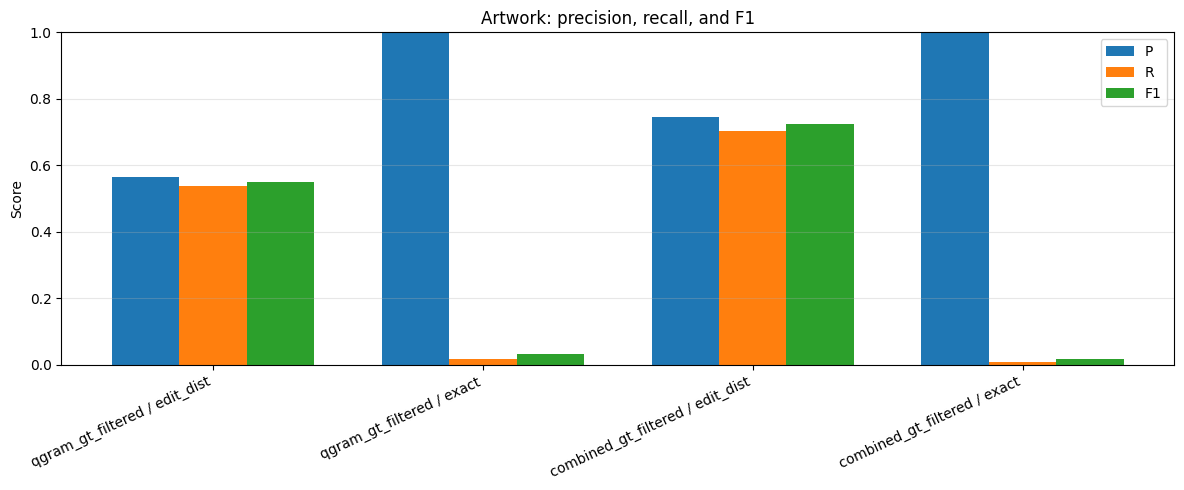

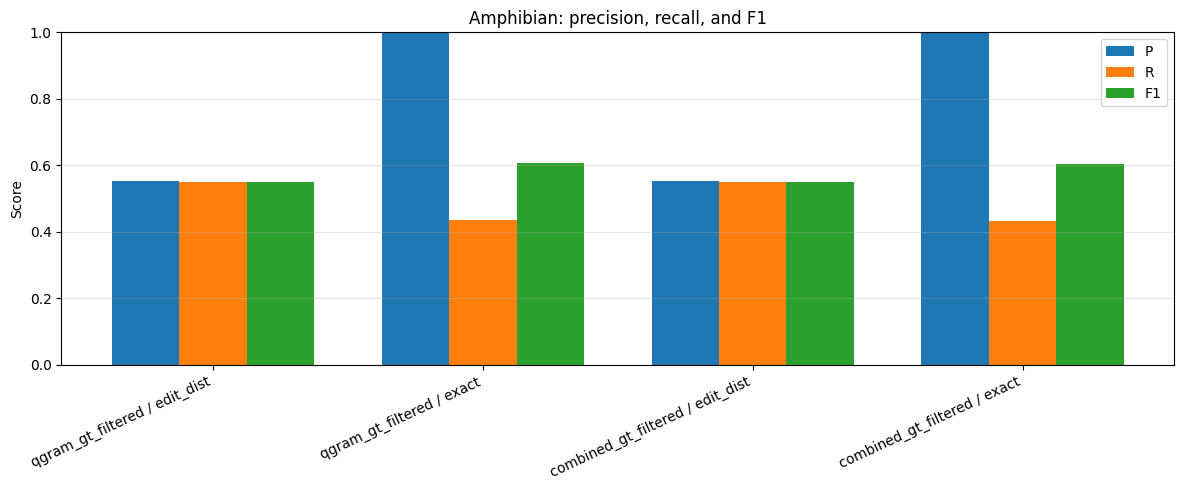

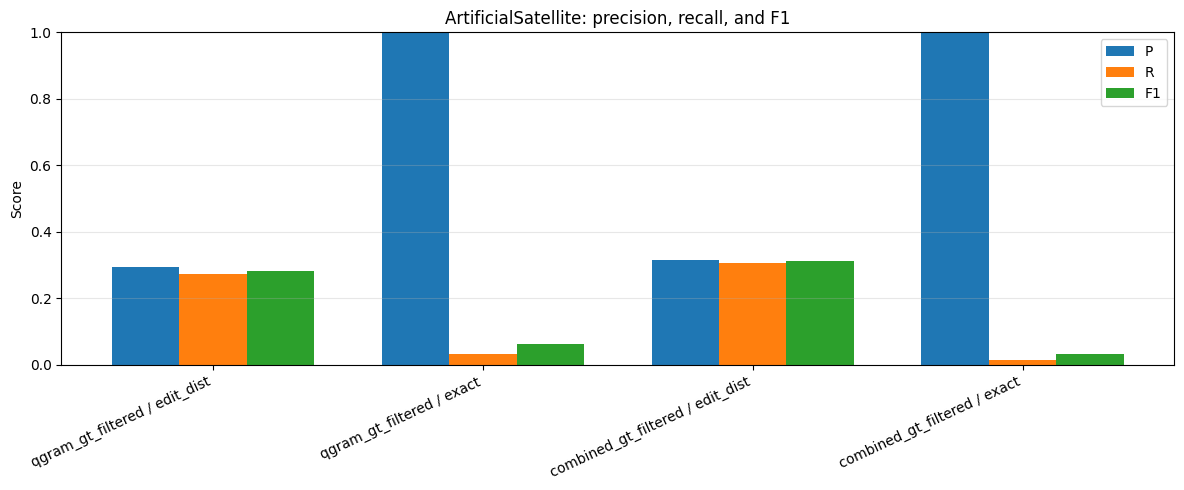

In [ ]:
def plot_metric_grouped(df, dataset, metrics=("P", "R", "F1")):
    d = df[df["dataset"] == dataset].copy()
    if d.empty:
        print(f"No rows for {dataset}")
        return

    labels = d["run"].tolist()
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, metric in enumerate(metrics):
        ax.bar(x + (i - 1) * width, d[metric].values, width, label=metric)

    ax.set_title(f"{dataset}: precision, recall, and F1")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

for dataset in TARGET_DATASETS:
    plot_metric_grouped(cur, dataset)

## F1 comparison across all runs


C:\Users\Kai\AppData\Local\Temp\ipykernel_40732\4195017197.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d["label"], rotation=45, ha="right")


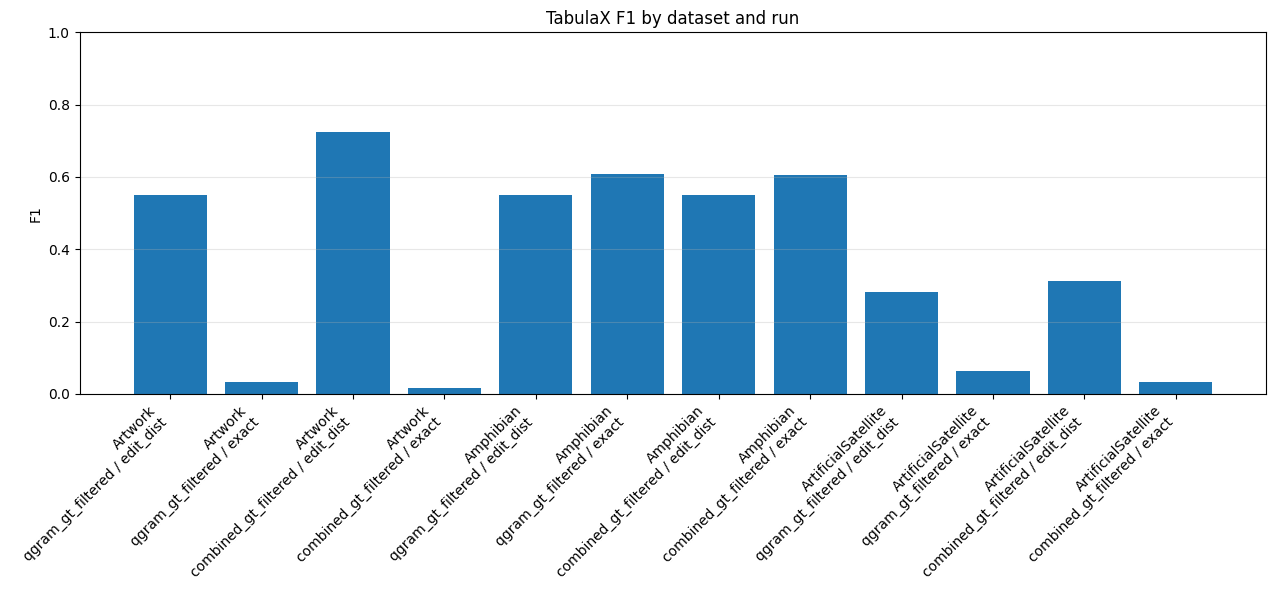

In [ ]:
def plot_f1_all(df):
    d = df.copy()
    if d.empty:
        print("No rows to plot")
        return
    d["label"] = d["dataset"] + "\n" + d["run"]
    d = d.sort_values(["dataset_order", "selector_order", "matching_order"])

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(d["label"], d["F1"])
    ax.set_title("TabulaX F1 by dataset and run")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(d["label"], rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_f1_all(cur)

## Edit-distance vs exact matching gap


In [ ]:
f1_pivot = cur.pivot_table(
    index=["dataset", "example_selector"],
    columns="matching",
    values="F1",
    aggfunc="first",
).reset_index()

if "edit_dist" in f1_pivot.columns and "exact" in f1_pivot.columns:
    f1_pivot["edit_minus_exact"] = f1_pivot["edit_dist"] - f1_pivot["exact"]

f1_pivot.sort_values(["dataset", "example_selector"])

matching,dataset,example_selector,edit_dist,exact,edit_minus_exact
0,Amphibian,combined_gt_filtered,0.551092,0.604736,-0.053644
1,Amphibian,qgram_gt_filtered,0.551092,0.607273,-0.056181
2,ArtificialSatellite,combined_gt_filtered,0.311475,0.031746,0.279729
3,ArtificialSatellite,qgram_gt_filtered,0.283333,0.062500,0.220833
4,Artwork,combined_gt_filtered,0.724062,0.017021,0.707041
5,Artwork,qgram_gt_filtered,0.550661,0.033755,0.516906


C:\Users\Kai\AppData\Local\Temp\ipykernel_40732\3710285579.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d["label"], rotation=35, ha="right")


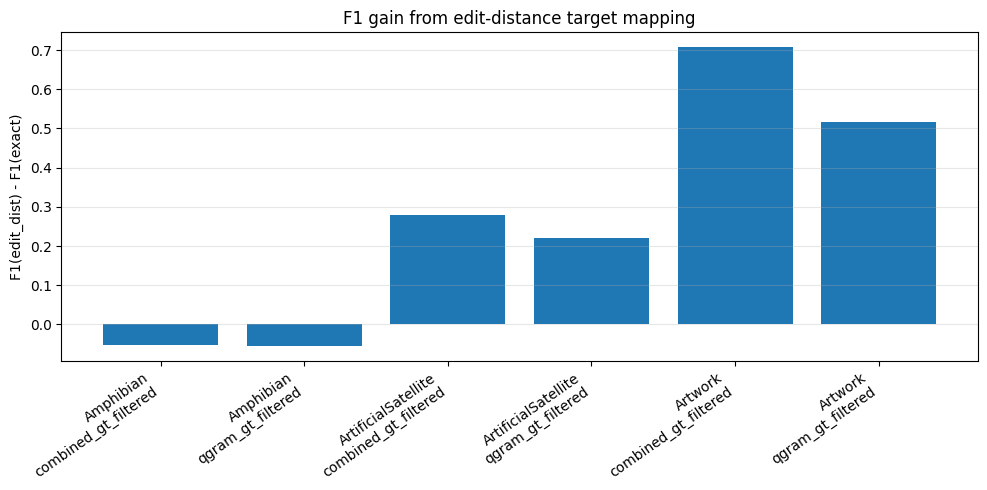

In [ ]:
if "edit_minus_exact" in f1_pivot.columns:
    d = f1_pivot.dropna(subset=["edit_minus_exact"]).copy()
    d["label"] = d["dataset"] + "\n" + d["example_selector"]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(d["label"], d["edit_minus_exact"])
    ax.set_title("F1 gain from edit-distance target mapping")
    ax.set_ylabel("F1(edit_dist) - F1(exact)")
    ax.set_xticklabels(d["label"], rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Need both edit_dist and exact runs to compute this gap.")

## Raw prediction correctness before edit-distance mapping

C:\Users\Kai\AppData\Local\Temp\ipykernel_40732\630182783.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d["label"], rotation=45, ha="right")


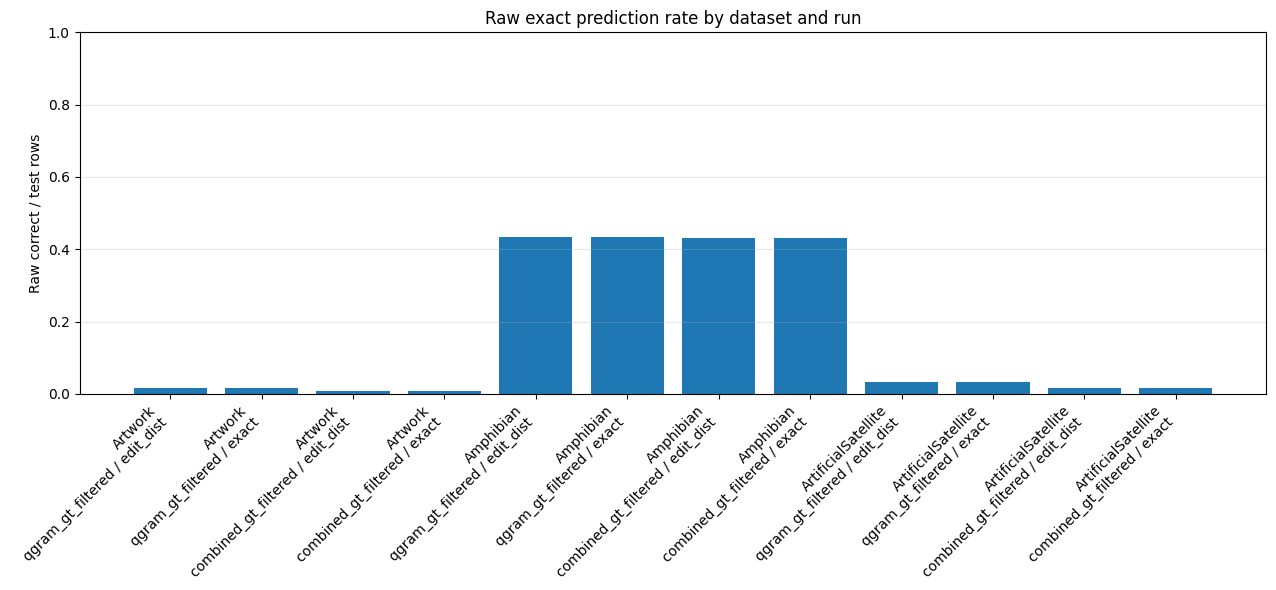

In [ ]:
def plot_raw_correct_rate(df):
    d = df.copy()
    if d.empty:
        print("No rows to plot")
        return
    d["label"] = d["dataset"] + "\n" + d["run"]
    d = d.sort_values(["dataset_order", "selector_order", "matching_order"])

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(d["label"], d["raw_correct_rate"])
    ax.set_title("Raw exact prediction rate by dataset and run")
    ax.set_ylabel("Raw correct / test rows")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(d["label"], rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_raw_correct_rate(cur)

## Runtime


C:\Users\Kai\AppData\Local\Temp\ipykernel_40732\2637164580.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d["label"], rotation=45, ha="right")


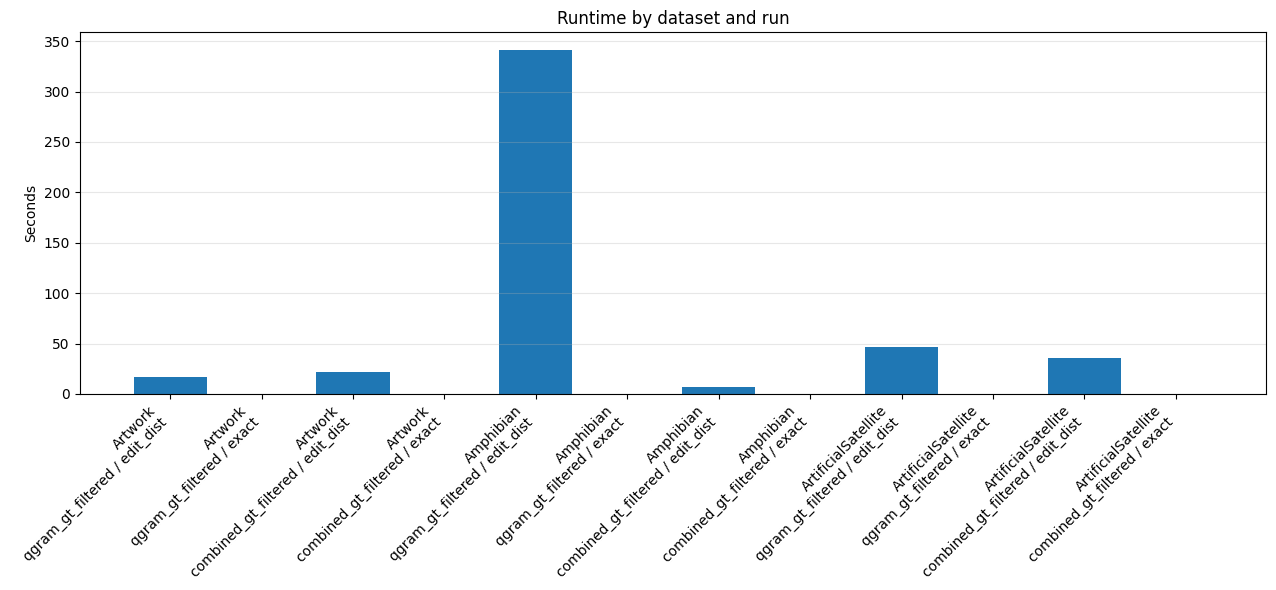

In [ ]:
def plot_runtime(df):
    d = df.copy()
    if d.empty:
        print("No rows to plot")
        return
    d["label"] = d["dataset"] + "\n" + d["run"]
    d = d.sort_values(["dataset_order", "selector_order", "matching_order"])

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(d["label"], d["time_sec"])
    ax.set_title("Runtime by dataset and run")
    ax.set_ylabel("Seconds")
    ax.set_xticklabels(d["label"], rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_runtime(cur)

## Best run per dataset


In [ ]:
best = cur.sort_values("F1", ascending=False).groupby("dataset", as_index=False).head(1)
best[["dataset", "example_selector", "matching", "class", "P", "R", "F1", "correct", "n_test", "raw_correct_rate", "time_sec", "run_folder"]]

,dataset,example_selector,matching,class,P,R,F1,correct,n_test,raw_correct_rate,time_sec,run_folder
8,Artwork,combined_gt_filtered,edit_dist,String,0.745455,0.703863,0.724062,2,235,0.008511,21.501486,autofj_Artwork_combined_gt_filtered_seed0_edit
3,Amphibian,qgram_gt_filtered,exact,String,1.000000,0.436031,0.607273,501,1151,0.435274,0.015000,autofj_Amphibian_qgram_gt_filtered_seed0_exact
4,ArtificialSatellite,combined_gt_filtered,edit_dist,General,0.316667,0.306452,0.311475,1,62,0.016129,36.029126,autofj_ArtificialSatellite_combined_gt_filtere...


## Export cleaned summary CSV

In [ ]:
out_path = TABULAX_ROOT / "tabulax_autofj_summary.csv"
summary.to_csv(out_path, index=False)
print("Wrote:", out_path)

Wrote: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\tabulax_autofj_summary.csv
